# Import

In [74]:
%load_ext autoreload
%autoreload 2

import traceback    
import os ; import sys
sys.path.insert(0, os.path.abspath(os.path.join('./lib')))

import test
import utilities
import harmonics
import detect_ignition
from session_metadata import parse_session_metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from typing import Dict, List, Optional, Sequence, Tuple

from scipy.signal import firwin, filtfilt, hilbert, welch
from dataclasses import dataclass
from dataclasses import asdict

from scipy.signal import savgol_filter


import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 128

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load EEG Data

In [64]:
FILES = [
    'data/test schumann_EPOCX_111270_2023.04.23T14.50.35.05.00.md.pm.bp.csv',
    'data/Test_06.11.20_14.28.18.md.pm.bp.csv',
    'data/20201229_29.12.20_11.27.57.md.pm.bp.csv',
    'data/med_EPOCX_111270_2021.06.12T09.50.52.04.00.md.bp.csv',
    'data/binaural_EPOCX_111270_2021.06.17T10.04.52.04.00.md.bp.csv',
]

def list_csv_files(directory):
    return [(directory+"/"+f) for f in os.listdir(directory) if f.endswith('.csv')]
    
KAGGLE = list_csv_files("data/mainData")
MPENG = list_csv_files("data/mpeng")
MPENG1 = list_csv_files("data/mpeng1")
MPENG2 = list_csv_files("data/mpeng2")
VEP = list_csv_files("data/vep")
PHYSF = list_csv_files("data/PhySF")
INSIGHT = list_csv_files("data/insight")
MUSE = list_csv_files("data/muse")
AREEG = list_csv_files("data/ArEEG")

ELECTRODES = ['EEG.AF3','EEG.AF4',
              'EEG.F3','EEG.F4',
              'EEG.F7','EEG.F8',
              'EEG.FC5','EEG.FC6',
              'EEG.P7','EEG.P8',
              'EEG.O1','EEG.O2',
              'EEG.T7','EEG.T8']

INSIGHT_ELECTRODES = ['EEG.AF3','EEG.AF4','EEG.T7','EEG.T8','EEG.Pz']
MUSE_ELECTRODES = ['EEG.AF7','EEG.AF8','EEG.TP9','EEG.TP10']

ELECTRODES = ELECTRODES

# FILENAME = MUSE[0]
# FILENAME = INSIGHT[0]
# FILENAME = PHYSF[0]
# FILENAME = PHYSF[0]

In [3]:
FILE =  FILES[0] # FILES[0]
HEADER = 1

RECORDS = utilities.load_eeg_csv(FILE, electrodes=ELECTRODES,header=HEADER)

# START = 0 ; END = 1146
# RECORDS = RECORDS.iloc[START*128:END*128].reset_index(drop=True)

RECORDS['Timestamp'] = RECORDS['Timestamp'] - RECORDS['Timestamp'].iloc[0]

# Detect Ignitions & Six Panel

######################### PROCESSING:  test schumann_EPOCX_111270_2023.04.23T14.50.35.05.00.md.pm.bp
Running session-level FOOOF harmonic detection...
  FOOOF harmonics: ['7.72', '9.97', '12.20', '13.75', '15.50', '19.50', '24.44', '32.88', '39.46']
  Aperiodic β: [0.765, 0.765, 1.876, 3.266, 2.213, 1.528, 2.725, 3.366, 8.862]
  R²: [0.883, 0.883, 0.908, 0.916, 0.883, 0.617, 0.755, 0.712, 0.941]
  Using per-event FOOOF for refinement...


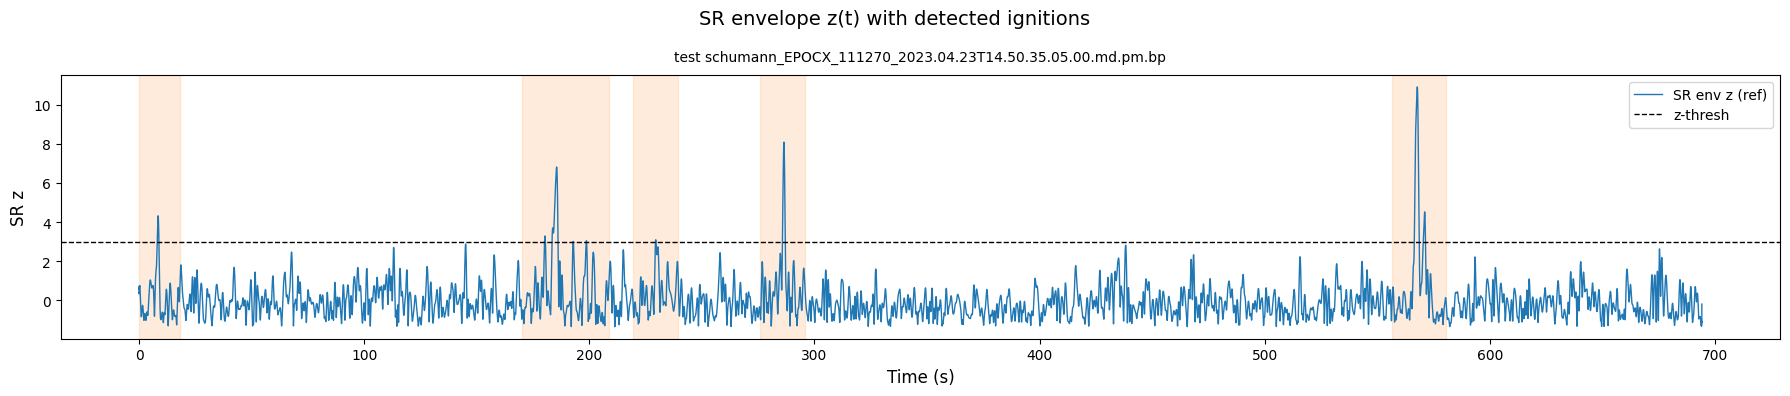


=== Ignition Detection — Session Summary ===

Session: test schumann_EPOCX_111270_2023.04.23T14.50.35.05.00.md.pm.bp
Session SR (FOOOF session):     [ 7.72  9.97 12.2  13.75 15.5  19.5  24.44 32.88 39.46]
Per-Event SR (FOOOF median):    [ 7.71 10.04 11.87 13.75 15.5  20.11 24.82 32.7  40.27]
Canonical SR (input):           [ 7.6  10.   12.   13.75 15.5  20.   25.   32.   40.  ]

Ignition windows: [(0, 19), (170, 209), (219, 240), (275, 296), (556, 581)]
EEG channels (n=14): AF3, AF4, F3, F4, F7, F8, FC5, FC6, P7, P8, O1, O2, T7, T8
Detection band: 7.60±[0.60, 0.62, 0.70, 0.75, 0.80, 1.00, 1.50, 2.00, 3.00] Hz; z-thresh=3.00; window=20.0s; min_ISI=2.0s
Event SR mode: auto-SSD

Events detected: 5
  sr1 z max (ref)      — median [IQR]: 6.81 [4.32, 8.08]
  sr1.5 z max (ref)      — median [IQR]: 2.94 [2.74, 3.63]
  sr2 z max (ref)      — median [IQR]: 3.86 [2.46, 3.93]
  MSC@sr1 (virtual)    — median [IQR]: 0.61 [0.58, 0.63]
  PLV@sr1 (±5 s)       — median [IQR]: 0.72 [0.68, 0.75]
  HSI (h

In [19]:
FREQS = [5,45]


# CANON =           [7.6,     12,           20,         25,     32,       40]
# HALF_BW     =     [0.6,    0.666,        1,       1.5,      2,       2,]
# FREQ_RANGES =     [[5, 15], [10, 20],     [15, 25], [20,30], [27, 37], [35,45]]

LABELS = ['sr1', 'sr1.5', 'sr2', 'sr2o', 'sr2.5', 'sr3', 'sr4', 'sr5', 'sr6']
CANON =           [ 7.6,    10,       12,       13.75,  15.5,     20,        25,     32,     40]
HALF_BW     =     [ 0.6,    0.618,    0.7,      0.75,   0.8,        1,        1.5,     2,      3,]
FREQ_RANGES =     [[5, 15], [5, 15],  [7,17],   [9,19], [10, 20], [15,25],   [20,30], [30,40], [35,45]]


SESSION_NAME = os.path.splitext(os.path.basename(FILE))[0]
print("######################### PROCESSING: ", SESSION_NAME)
# print("SR estimate: ",["{:.2f}".format(x) for x in HARMONICS])

IGN_OUT, IGNITION_WINDOWS = detect_ignition.detect_ignitions_session(
    RECORDS,
    eeg_channels= ELECTRODES,    
    center_hz= CANON[0], 
    harmonics_hz= CANON,
    half_bw_hz= HALF_BW,
    labels=LABELS,
    smooth_sec= 0.01,
    z_thresh= 3,
    min_isi_sec= 2.0, 
    window_sec= 20, 
    merge_gap_sec= 10,
    R_band= (CANON[0]-HALF_BW[0],CANON[0]+HALF_BW[0]),
    # R_win_sec= 15, 
    # R_step_sec= 0.1,
    # eta_pre_sec= 3.0, 
    # eta_post_sec= 3.0,
    sr_reference= 'auto-SSD', 
    seed_method= 'latency',
    # pel_band= (32,64),
    # harmonic_bw_hz = HARMONICS_BW_HZ,
    make_passport= False,
    show= True,
    verbose = True,
    session_name = SESSION_NAME,
    
    harmonic_method='fooof_hybrid',
    nperseg_sec=100.0,

    fooof_freq_range=FREQS,              # ✅ Correct 
    fooof_freq_ranges=FREQ_RANGES,       # ✅ Correct
    fooof_max_n_peaks=7,                # ✅ Correct # More peaks (default: 10)
    fooof_peak_threshold=0.1,           # ✅ Correct # Lower threshold (default: 2.0)
    fooof_min_peak_height=0.05,          # ✅ Correct # Lower floor (default: 0.05)
    fooof_peak_width_limits=(0.3, 4), # ✅ Correct # Wider range (default: (1.0, 8.0))
    fooof_match_method='average',          # ✅ New!
)

for idx, IGN_WIN in enumerate(IGNITION_WINDOWS):
# idx = 8
# IGN_WIN=IGNITION_WINDOWS[idx]
    
    CFG = test.FeaturePackCfg(
        channels=ELECTRODES, time_col='Timestamp', fs=128,
        win_sec=6.0, 
        step_sec=0.01,
        spec_win= 1.5,
        spec_ovl= 0.95,
        sr_centers=IGN_OUT['events']['ignition_freqs'][idx],
        ladder=IGN_OUT['events']['ignition_freqs'][idx],
        bw_hz=HALF_BW,
    )
    
    # PALETTE = 'aquatic'
    # fig = test.sr_signature_panel(RECORDS,ELECTRODES,IGN_WIN,IGN_OUT,IGN_OUT['events']['ignition_freqs'][idx],CFG,SESSION_NAME,palette=PALETTE) ; fig.show()
    # test.six_panel(RECORDS,ELECTRODES,IGN_WIN,IGN_OUT,IGN_OUT['events']['ignition_freqs'][idx],CFG,SESSION_NAME)
    # fig = test.six_panel_2(RECORDS, ELECTRODES, IGN_WIN, IGN_OUT, IGN_OUT['events']['ignition_freqs'][idx], CFG, SESSION_NAME) ; fig.show()
    
    continue

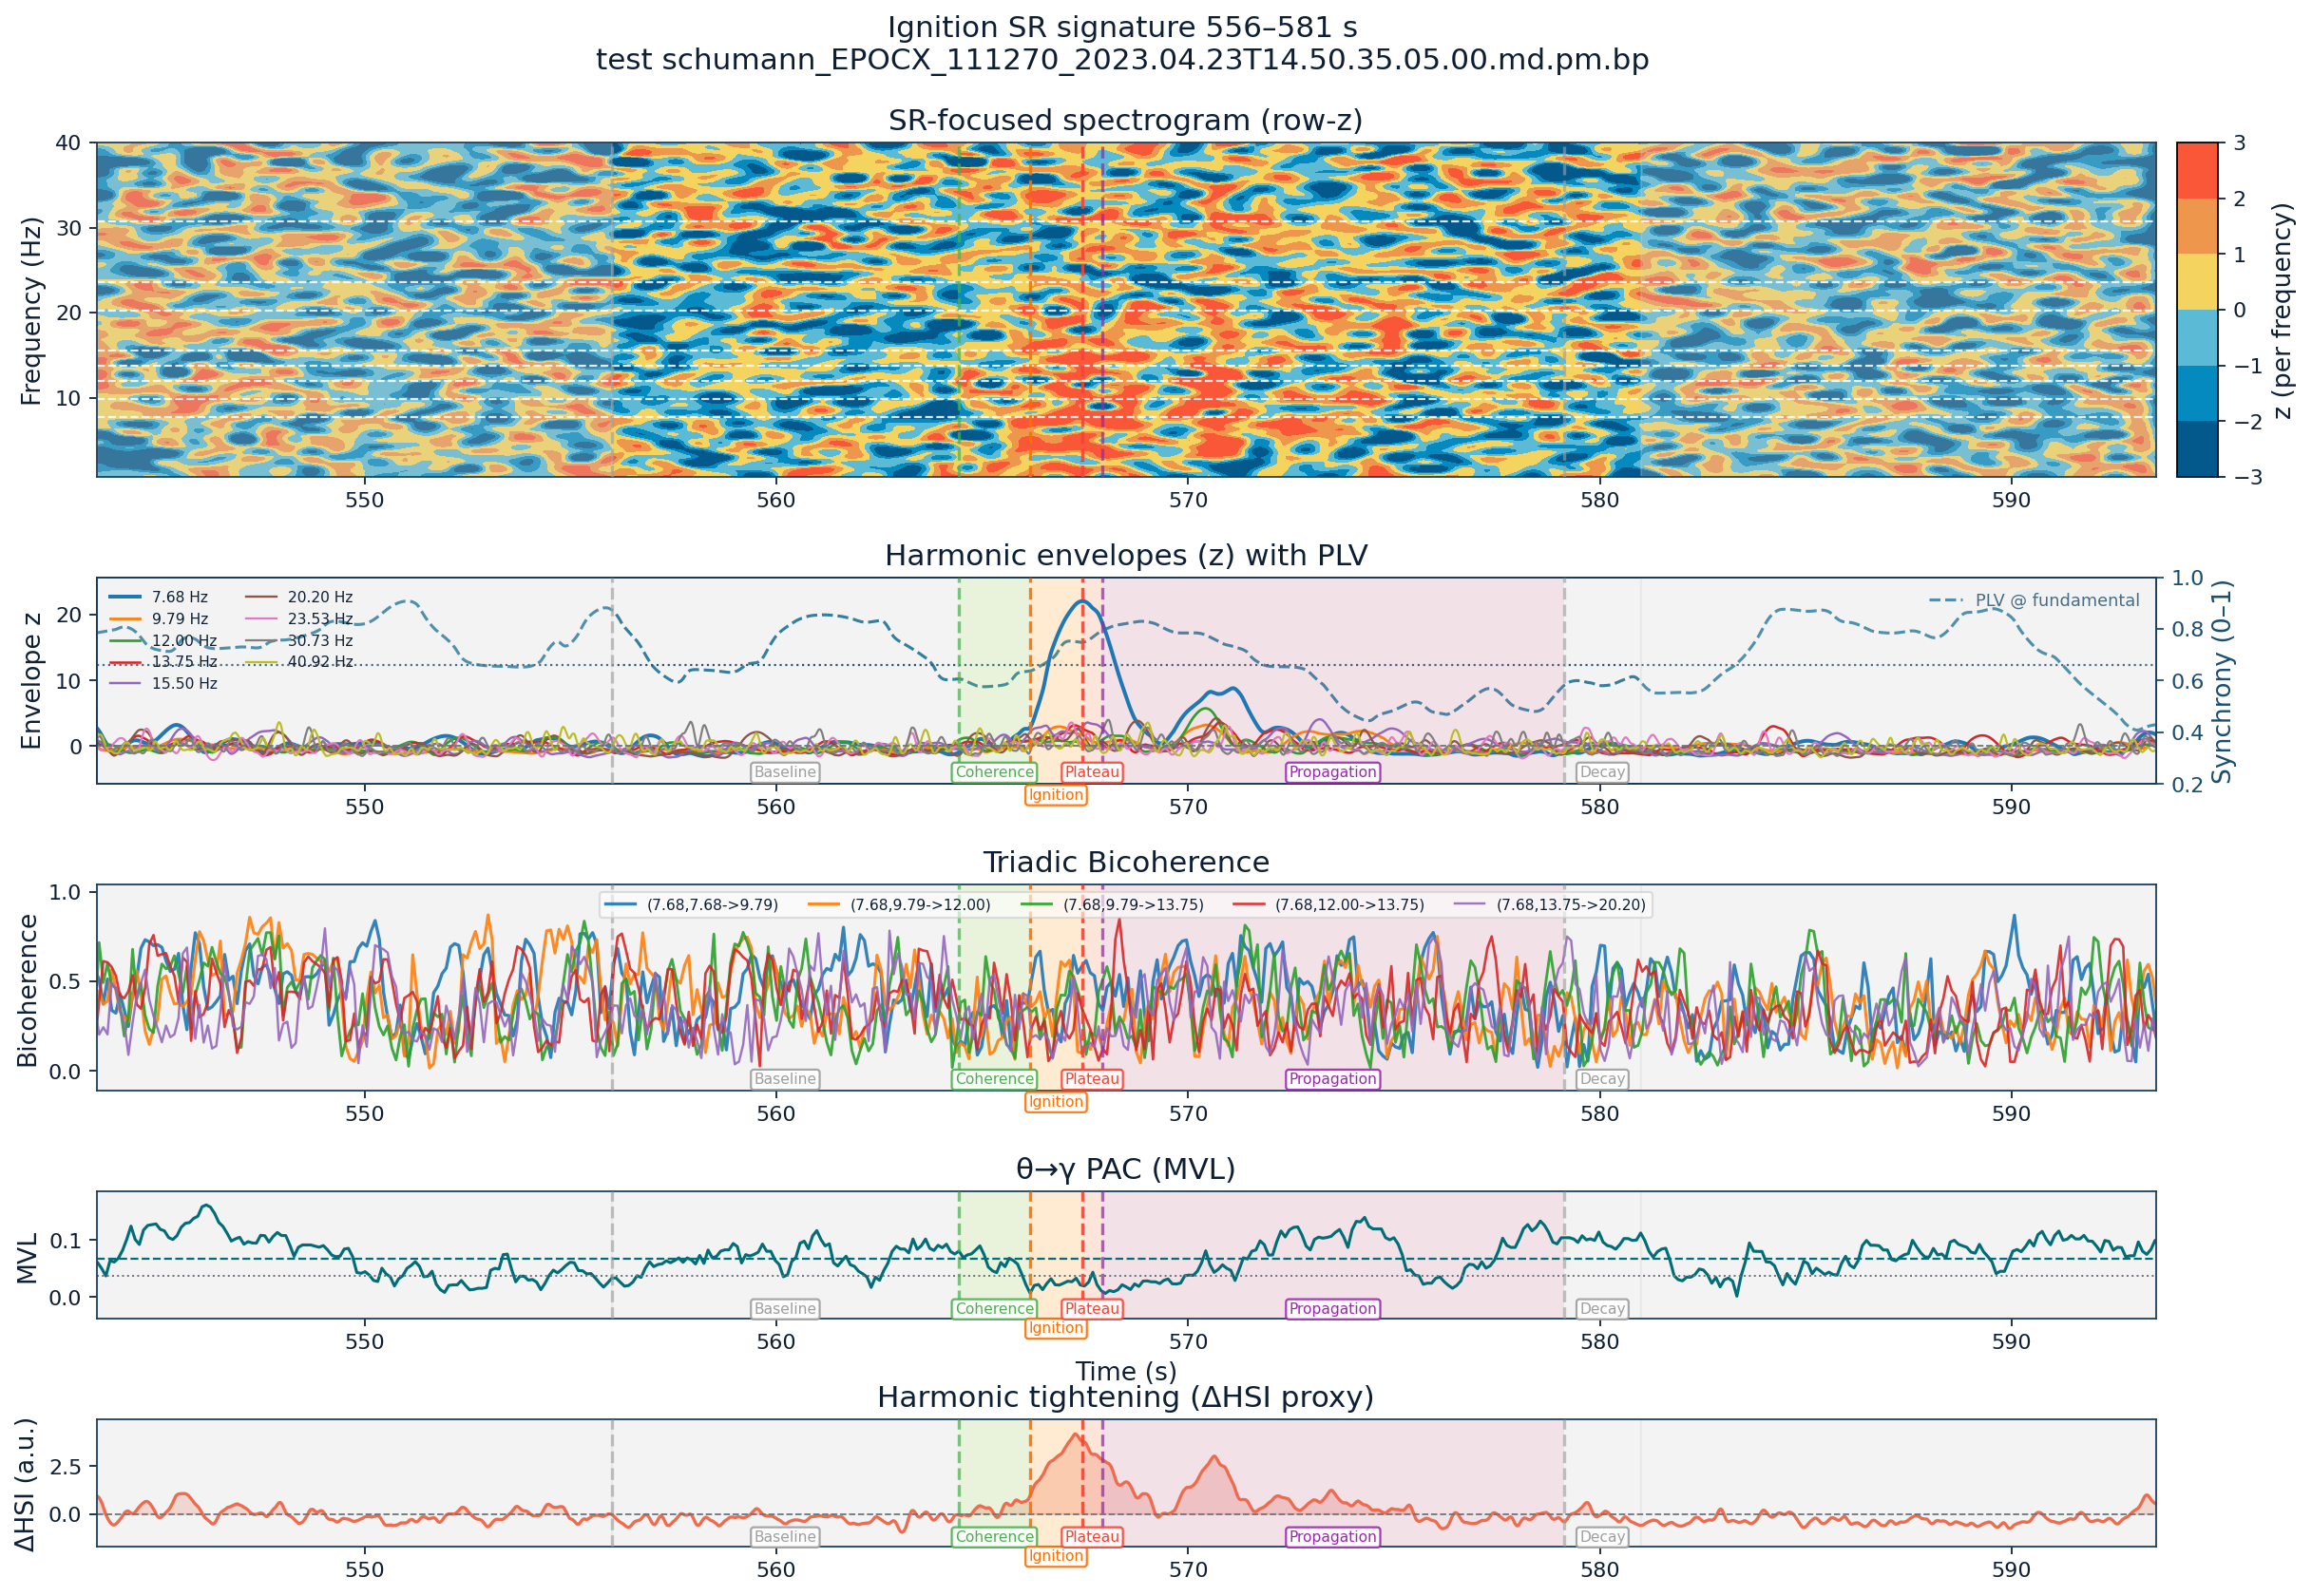

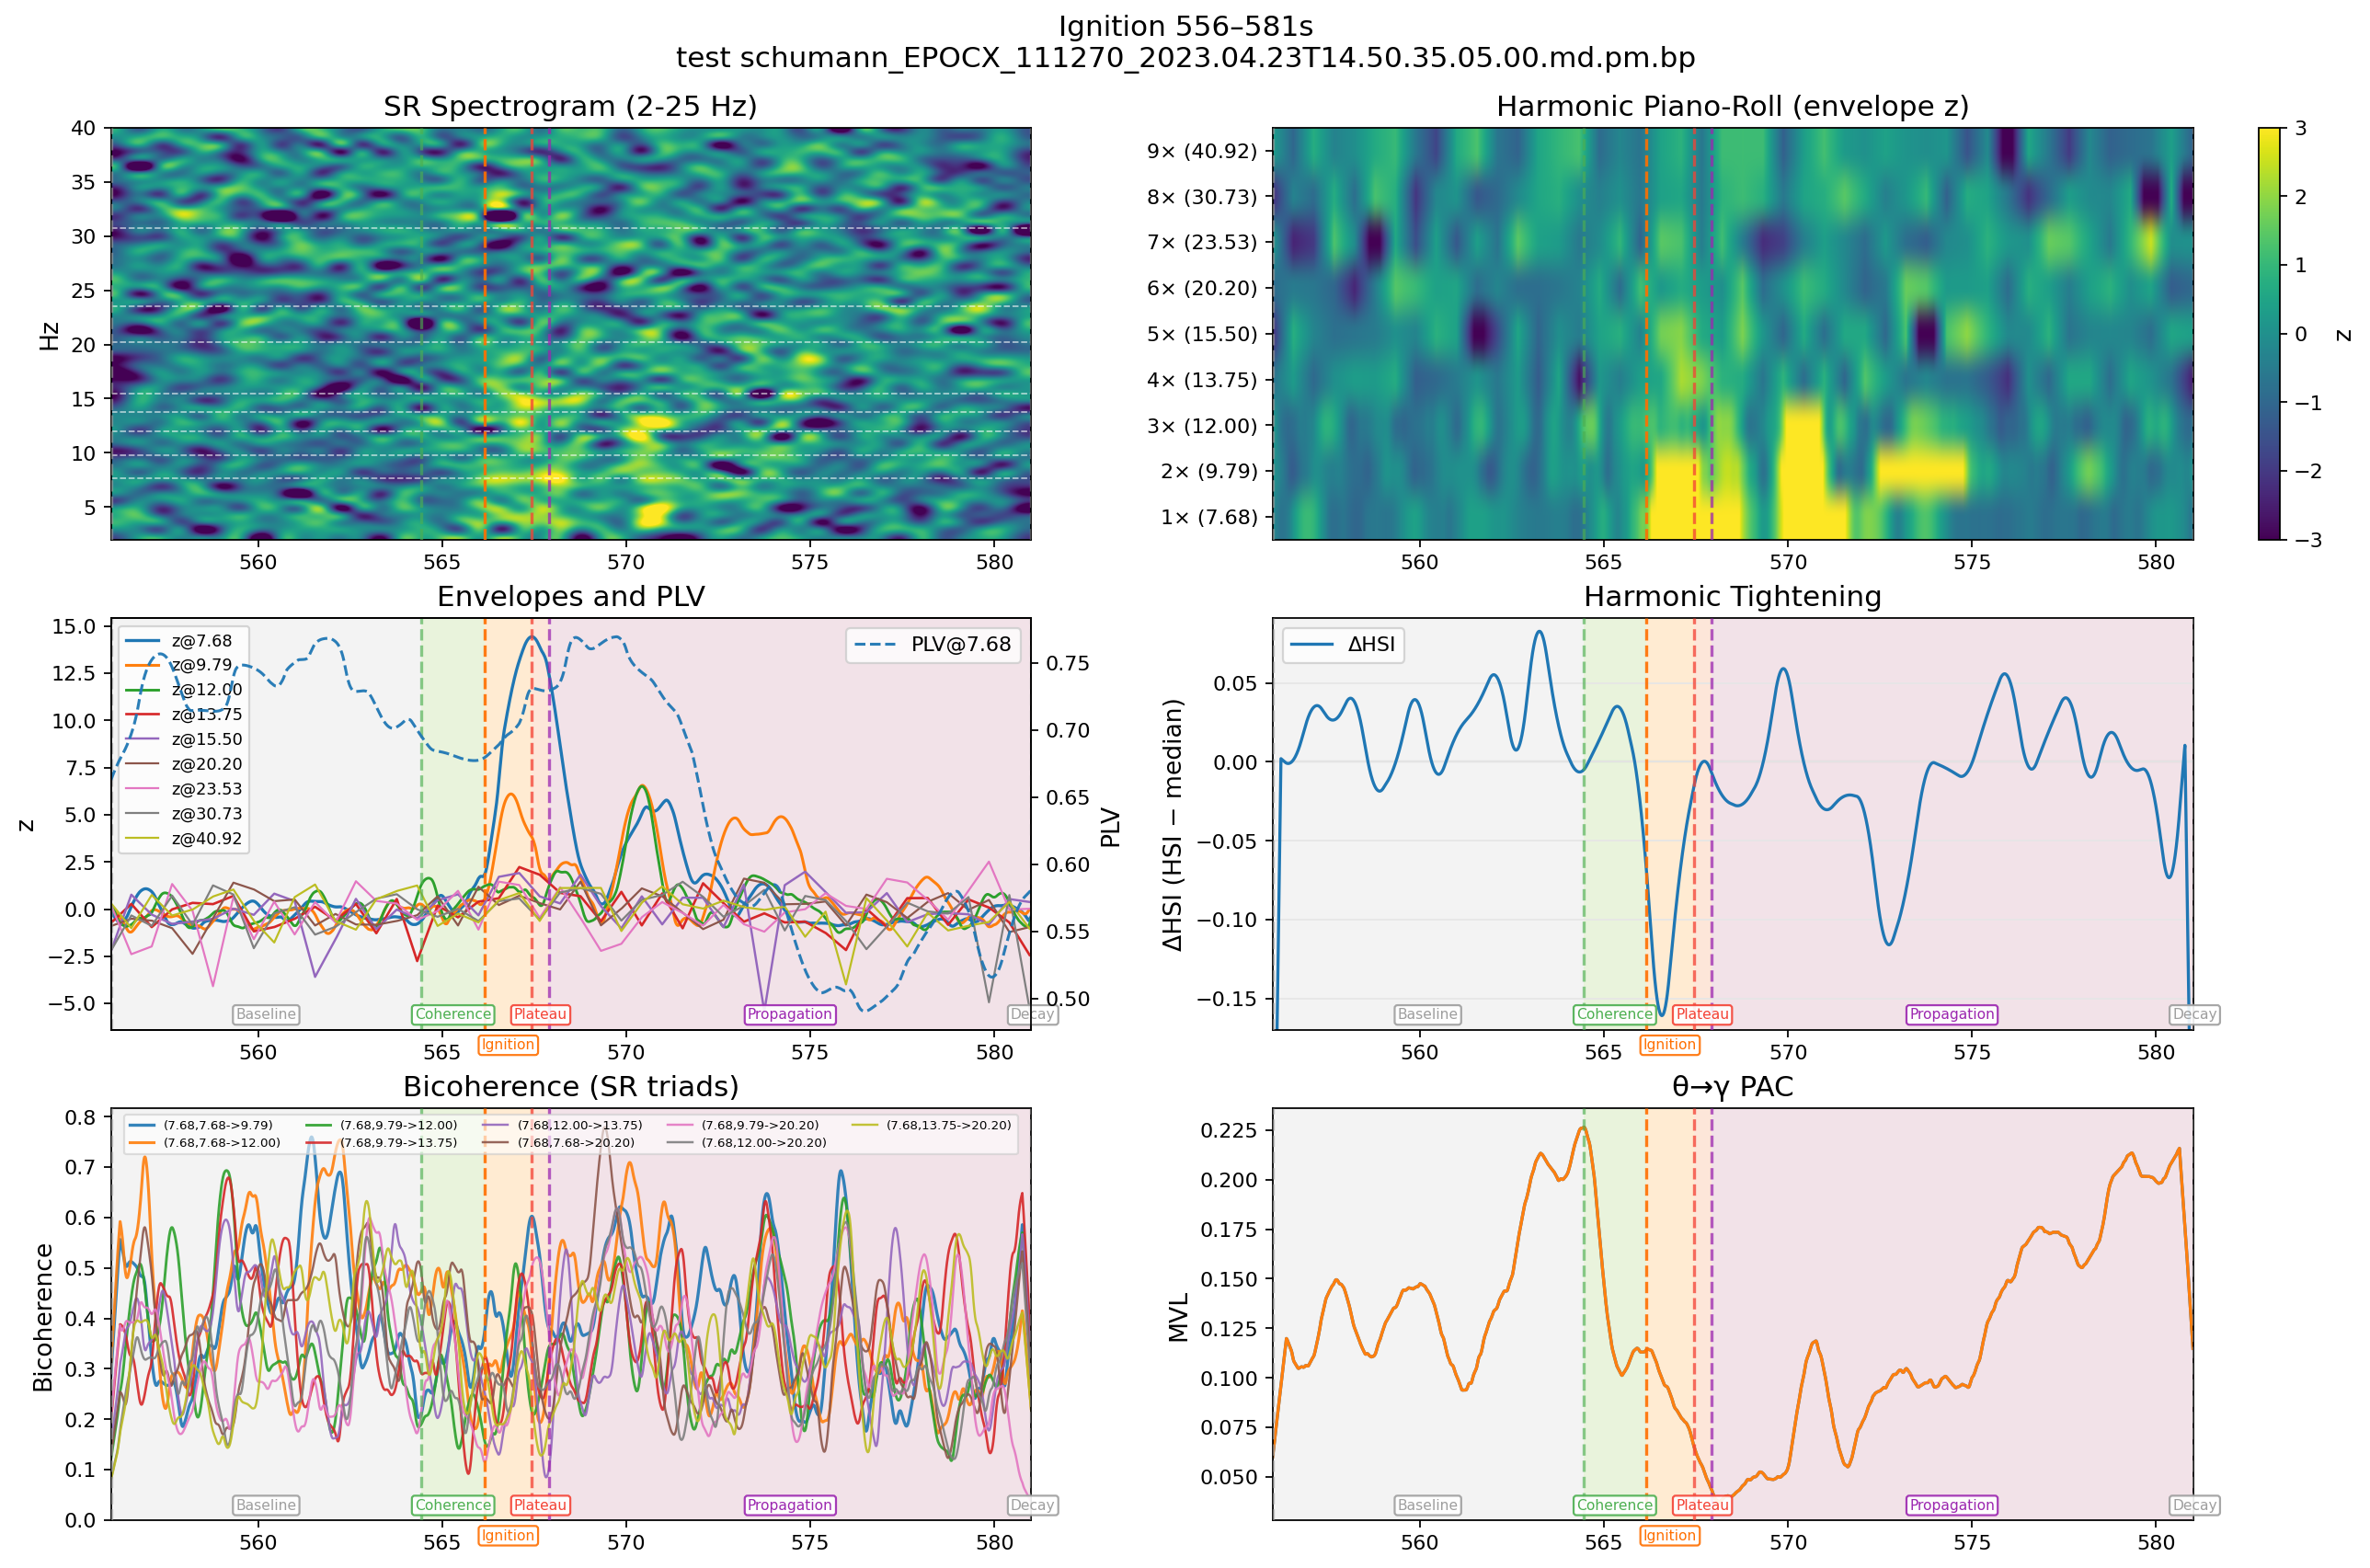

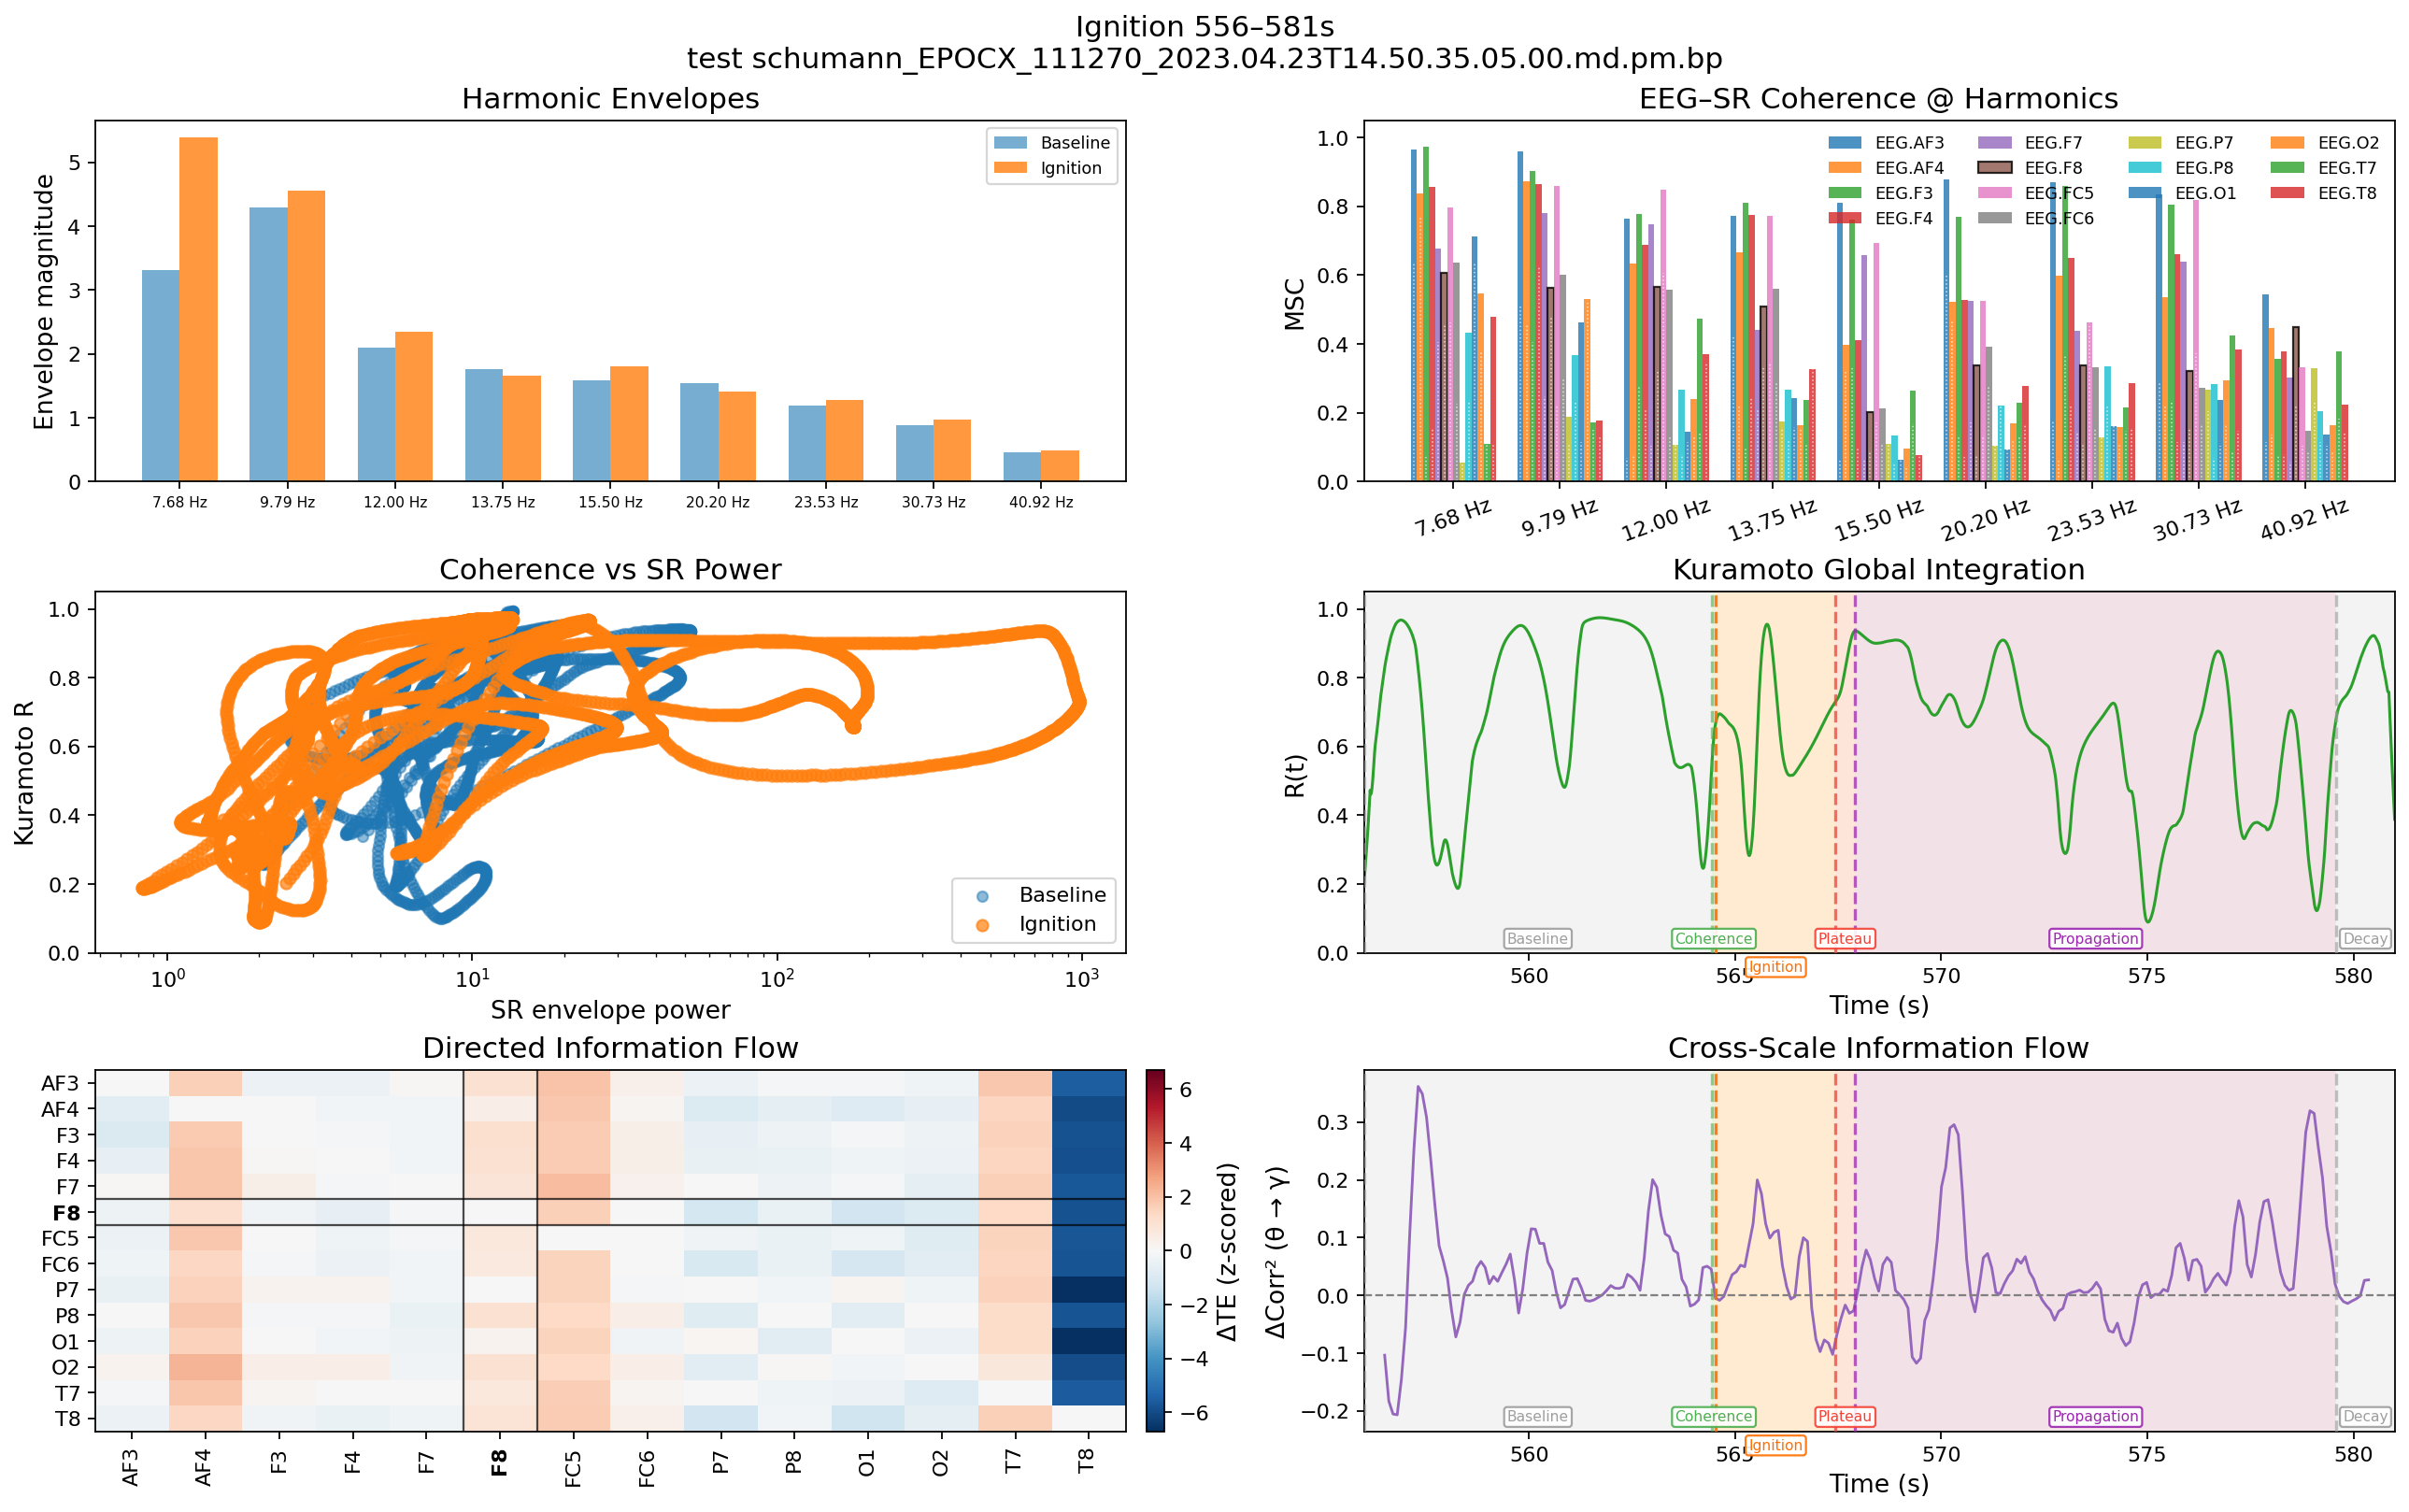

In [61]:
idx = 4 ; IGN_WIN=IGNITION_WINDOWS[idx]

# for idx, IGN_WIN in enumerate(IGNITION_WINDOWS):
if True:
    CFG = test.FeaturePackCfg(
        channels=ELECTRODES, time_col='Timestamp', fs=128,
        win_sec=6.0, 
        step_sec=0.01,
        spec_win= 1.5,
        spec_ovl= 0.95,
        sr_centers=IGN_OUT['events']['ignition_freqs'][idx],
        ladder=IGN_OUT['events']['ignition_freqs'][idx],
        bw_hz=HALF_BW,
    )
        
    PALETTE = 'aquatic'
    fig = test.sr_signature_panel(RECORDS,ELECTRODES,IGN_WIN,IGN_OUT,IGN_OUT['events']['ignition_freqs'][idx],CFG,SESSION_NAME,palette=PALETTE) ; fig.show()
    test.six_panel(RECORDS,ELECTRODES,IGN_WIN,IGN_OUT,IGN_OUT['events']['ignition_freqs'][idx],CFG,SESSION_NAME)
    fig = test.six_panel_2(RECORDS, ELECTRODES, IGN_WIN, IGN_OUT, IGN_OUT['events']['ignition_freqs'][idx], CFG, SESSION_NAME) ; fig.show()

# FOOOF 

In [ ]:
###### # Compare naive vs FOOOF detection
fig, result = fooof_harmonics.compare_psd_fooof(
    records=RECORDS,
    channels=ELECTRODES,
    fs=128,
    f_can=CANON,
    freq_ranges=FREQ_RANGES,
    freq_range=FREQS,
    
    # NEW PARAMETERS:
    max_n_peaks=20,              # More peaks (default: 10)
    peak_threshold=0.01,         # Lower threshold (default: 2.0)
    min_peak_height=0.01,        # Lower floor (default: 0.05)
    peak_width_limits=(0.5, 12.0),  # Wider range (default: (1.0, 8.0))
    search_halfband=HALF_BW,
    
    match_method='power',
)
print(result)

# Now plot just the periodic component panel, larger:
fig_periodic = fooof_harmonics.plot_fooof_periodic(
    result,
    f_can=CANON,
    freq_range=(5, 45),
    figsize=(12, 7),  # Larger size
    title='FOOOF Periodic Component — Detected Harmonics'
)

plt.show()
# Or save it:
# fig_periodic.savefig('periodic_only.png', dpi=150, bbox_inches='tight')

# 1. Run FOOOF detection on a time window
# t0 = 567  # Event time
harmonics, result = fooof_harmonics.detect_harmonics_fooof(
    RECORDS, ELECTRODES, fs=128,
    # window=[t0 - 10, t0 + 10],
    f_can=CANON,
    freq_range=FREQS,
    freq_ranges=FREQ_RANGES,
    search_halfband=HALF_BW,
    
    max_n_peaks=15,              # More peaks (default: 10)
    peak_threshold=0.01,         # Lower threshold (default: 2.0)
    min_peak_height=0.01,        # Lower floor (default: 0.05)
    peak_width_limits=(0.5, 12.0),  # Wider range (default: (1.0, 8.0))
    
    match_method='power',
)

# 2. Now 'harmonics' contains your detected frequencies (list of 7 floats)
print(f"Detected harmonics: {harmonics}","\n")
# Example output: [7.81, 9.86, 12.18, 13.75, 19.06, 24.97, 32.68]

In [ ]:
t0 = 283

CANON = [7.6, 10, 12.13, 13.75, 19.75, 25, 32]
HALF_BW = [0.5, 0.618, 0.618, 0.75, 0.75, 1.25, 1.5]

# Define grouped 10 Hz windows
FREQ_RANGES = [
    [5, 15],   # H1, H2, H3, H4 (4 harmonics share this fit)
    [5, 15],
    [5, 15],
    [5, 15],
    [15, 25],  # H5 (1 harmonic)
    [22, 32],  # H6, H7 (2 harmonics share this fit)
    [27, 37]
]

harmonics, result = fooof_harmonics.detect_harmonics_fooof(
    RECORDS, ELECTRODES, fs=128,
    # window=[t0 - 10, t0 + 10],
    f_can=CANON,
    freq_ranges=FREQ_RANGES,  # NEW PARAMETER!
    search_halfband=HALF_BW,
    match_method='average',
    max_n_peaks=10
)
print(harmonics)

In [ ]:

# CHECK WHAT FOOOF ACTUALLY DETECTED IN EACH WINDOW
print("=" * 70)
print("FOOOF PEAKS DETECTED PER HARMONIC:")
print("=" * 70)

for i, (f0, halfband, fm) in enumerate(zip(CANON, HALF_BW, result.model)):
    print(f"\nH{i+1} ({f0} Hz) - Search window: [{f0-5:.2f}, {f0+5:.2f}] Hz")
    print(f"    Peak matching window: [{f0-halfband:.2f}, {f0+halfband:.2f}] Hz")
    
    if fm is None:
        print("    ⚠️  FOOOF fit FAILED")
        continue
    
    # Get all peaks FOOOF detected in this ±5 Hz window
    peaks = fm.results.params.periodic.params  # specparam 2.0
    
    if len(peaks) == 0:
        print(f"    ⚠️  FOOOF found NO peaks in [{f0-5:.2f}, {f0+5:.2f}] Hz window")
        print(f"    → Returned canonical: {harmonics[i]:.2f}")
    else:
        print(f"    ✓ FOOOF found {len(peaks)} peak(s):")
        for j, peak in enumerate(peaks):
            freq, power, bw = peak
            in_search = (f0 - halfband) <= freq <= (f0 + halfband)
            marker = "✓" if in_search else "✗"
            print(f"      {marker} Peak {j+1}: {freq:.2f} Hz, power={power:.3f}, bw={bw:.2f}")
        print(f"    → Selected: {harmonics[i]:.2f} Hz")

print("\n" + "=" * 70)

In [ ]:
# Your data
harmonics, result = fooof_harmonics.detect_harmonics_fooof(
    RECORDS, ELECTRODES, fs=128,
    window=[564, 593],
    max_n_peaks=10,
    f_can=CANON
)

# Matched harmonics (what you asked for)
print("=" * 60)
print("MATCHED HARMONICS (near canonical frequencies)")
print("=" * 60)
canonical_freqs = CANON
for i, (harm, canonical) in enumerate(zip(harmonics, canonical_freqs)):
    if not np.isnan(harm):
        diff = harm - canonical
        print(f"H{i+1}: {harm:.2f} Hz (Δ{diff:+.2f} Hz from {canonical:.2f})")
    else:
        print(f"H{i+1}: NOT DETECTED (searched near {canonical:.2f})")

# All detected peaks (what FOOOF actually found)
print("\n" + "=" * 60)
print("ALL FOOOF PEAKS (independent of your search)")
print("=" * 60)

all_peaks = result.model.results.params.periodic.params
print(f"FOOOF detected {len(all_peaks)} total peaks:\n")

for peak in all_peaks:
    freq, power, bw = peak
    
    # Check if this was matched to any canonical harmonic
    matched_idx = None
    for i, h in enumerate(harmonics):
        if not np.isnan(h) and abs(h - freq) < 0.01:
            matched_idx = i
            break
    
    if matched_idx is not None:
        print(f"  {freq:6.2f} Hz | pow={power:5.2f} | bw={bw:4.2f} Hz → H{matched_idx+1}")
    else:
        print(f"  {freq:6.2f} Hz | pow={power:5.2f} | bw={bw:4.2f} Hz (unmatched)")

print("\n" + "=" * 60)
print(f"Quality: β={result.aperiodic_exponent:.3f}, R²={result.r_squared:.3f}")
print("=" * 60)

In [ ]:
print(IGN_OUT['events'])

# Six Panel - Batch


=== Processing FILES: 5 files ===


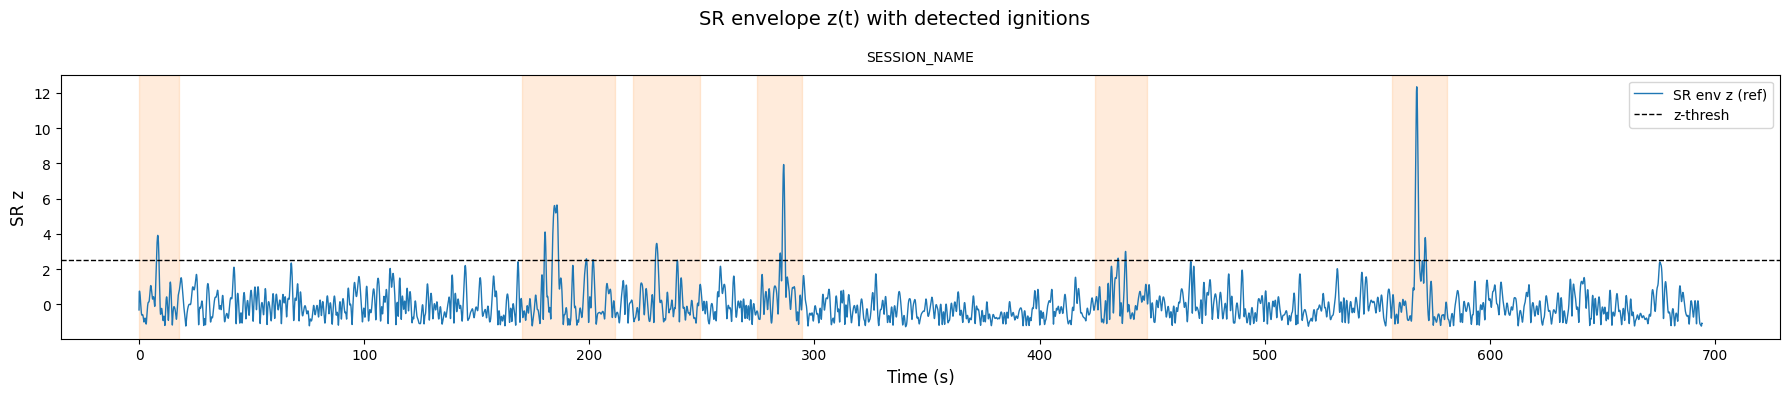


=== Ignition Detection — Session Summary ===

Session: SESSION_NAME
Harmonic Centers:  [15.66 23.49 31.32 39.15 46.98 54.81]

Ignition windows: [(0, 18), (169, 212), (219, 250), (274, 295), (424, 448), (556, 581)]
EEG channels (n=14): AF3, F7, F3, FC5, T7, P7, O1, O2, P8, T8, FC6, F4, F8, AF4
Detection band: 7.83±0.50 Hz; z-thresh=2.50; window=20.0s; min_ISI=2.0s
Event SR mode: auto-SSD

Events detected: 6
  sr1 z max (ref)      — median [IQR]: 4.78 [3.57, 7.36]
  sr2 z max (ref)      — median [IQR]: 3.05 [2.73, 3.31]
  sr3 z max (ref)      — median [IQR]: 2.86 [2.29, 3.10]
  MSC@sr1 (virtual)    — median [IQR]: 0.45 [0.39, 0.47]
  PLV@sr1 (±5 s)       — median [IQR]: 0.66 [0.62, 0.70]
  HSI (harmonic stack)   — median [IQR]: 1.22 [1.03, 1.43]
  SR-Score               — median [IQR]: 0.26 [0.23, 0.31]
  Coverage of recording  — 22.55%

Top events by Score (sr1_z_max * msc * plv / (1 + HSI)):
t_start  t0_net sr_z_peak_t t_end duration_s  sr1   sr2   sr3   sr4   sr5   sr6  sr1_z_max sr2

KeyboardInterrupt: 

In [83]:
# Notebook Integration Code for Session Metadata

import sys; sys.path.insert(0, './lib')
import os
import pandas as pd
from session_metadata import parse_session_metadata
import utilities
import detect_ignition

# Constants
FS = 128
EPOC_ELECTRODES = ['EEG.AF3','EEG.F7','EEG.F3','EEG.FC5','EEG.T7','EEG.P7','EEG.O1',
                   'EEG.O2','EEG.P8','EEG.T8','EEG.FC6','EEG.F4','EEG.F8','EEG.AF4']
INSIGHT_ELECTRODES = ['EEG.AF3','EEG.AF4','EEG.T7','EEG.T8','EEG.Pz']

def list_csv_files(directory):
    if not os.path.exists(directory):
        return []
    return [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.csv')]

# Dataset configurations: (name, files, header, electrodes)
DATASETS = [
    ('files', [
        ('data/test schumann_EPOCX_111270_2023.04.23T14.50.35.05.00.md.pm.bp.csv', 1),
        ('data/Test_06.11.20_14.28.18.md.pm.bp.csv', 1),
        ('data/20201229_29.12.20_11.27.57.md.pm.bp.csv', 1),
        ('data/med_EPOCX_111270_2021.06.12T09.50.52.04.00.md.bp.csv', 1),
        ('data/binaural_EPOCX_111270_2021.06.17T10.04.52.04.00.md.bp.csv', 1),
    ], EPOC_ELECTRODES),
    ('physf', [(f, 0) for f in list_csv_files('data/PhySF')], EPOC_ELECTRODES),
    ('vep', [(f, 0) for f in list_csv_files('data/vep')], EPOC_ELECTRODES),
    ('mpeng1', [(f, 0) for f in list_csv_files('data/mpeng1')], EPOC_ELECTRODES),
    ('mpeng2', [(f, 0) for f in list_csv_files('data/mpeng2')], EPOC_ELECTRODES),
    ('insight', [(f, 1) for f in list_csv_files('data/insight')], INSIGHT_ELECTRODES),
]

# Collect all results
all_results = []

for dataset_name, files_list, electrodes in DATASETS:
    print(f"\n=== Processing {dataset_name.upper()}: {len(files_list)} files ===")
    
    for i, (filepath, header) in enumerate(files_list):
        filename = os.path.basename(filepath)
        
        if not os.path.exists(filepath):
            print(f"  [{i+1}/{len(files_list)}] {filename[:40]} - NOT FOUND")
            continue
        
        try:
            # Load EEG data
            RECORDS = utilities.load_eeg_csv(filepath, electrodes=electrodes, fs=FS, header=header)
            
            # Run ignition detection (adjust parameters as needed)
            out, IGNITION_WINDOWS = detect_ignition.detect_ignitions_session(
                RECORDS,
                sr_channel='EEG.F4' if 'EEG.F4' in electrodes else electrodes[0],
                eeg_channels=electrodes,
                # ... other parameters
            )
            
            # Get metadata
            metadata = parse_session_metadata(filepath, dataset_name)
            
            # Add metadata to results
            result = {
                'session': filename,
                'filepath': filepath,
                'n_ignitions': len(IGNITION_WINDOWS),
                **metadata,  # subject, device, context, dataset
                # Add any other metrics from 'out' dict...
            }
            
            all_results.append(result)
            
            if (i + 1) % 50 == 0:
                print(f"  [{i+1}/{len(files_list)}] Processed...")
                
        except Exception as e:
            print(f"  [{i+1}/{len(files_list)}] {filename[:40]} - ERROR: {e}")

# Create DataFrame with all results
results_df = pd.DataFrame(all_results)

# Reorder columns for clarity
cols = ['session', 'subject', 'device', 'context', 'dataset', 'n_ignitions', 'filepath']
cols = [c for c in cols if c in results_df.columns] + [c for c in results_df.columns if c not in cols]
results_df = results_df[cols]

# Save to CSV
results_df.to_csv('ignition_results_with_metadata.csv', index=False)
print(f"\nSaved {len(results_df)} sessions to ignition_results_with_metadata.csv")


In [105]:
LABELS =          ['sr1', ' sr1.5',  'sr2',     'sr2o', 'sr2.5', 'sr3',    'sr4', 'sr5', 'sr6']
CANON =           [ 7.6,    10,       12,       13.75,  15.5,     20,        25,     32,     40]
HALF_BW     =     [ 0.6,    0.618,    0.7,      0.75,   0.8,        1,         2,     2.5,      3,]
FREQ_RANGES =     [[5,15], [5, 15],  [7,17],   [12,22], [12, 22], [15,25],   [20,30], [30,40], [35,45]]



_half_bw     =     HALF_BW
_labels      =     LABELS


SESSION_HARM=[]
EVENT_HARM=[]

RESULTS = pd.DataFrame()


for _files in [(FILES,'files'), (INSIGHT,'insight'), (MUSE,'muse'), (PHYSF,'physf'), (VEP,'vep'), (MPENG1,'mpeng'), (MPENG2,'mpeng') ]:  # (FILES,'files'), (PHYSF,'physf'), (VEP,'vep'), (MPENG1,'mpeng'), (MPENG2,'mpeng')]:
    dataset_name = _files[1]
    
    for _file in _files[0]:
        # SESSION NAME
        _session_name = dataset_name + "_" + os.path.splitext(os.path.basename(_file))[0]
        
        print("### Session: ", _session_name)

        # GET METADATA using the new utility
        metadata = parse_session_metadata(_file, dataset_name)

        # Print metadata for visibility
        print(f"  → subject={metadata['subject']}, device={metadata['device']}, "
              f"context={metadata['context']}, dataset={metadata['dataset']}")
        
        # Use metadata for device/electrodes
        if metadata['device'] == 'insight':
            _electrodes = INSIGHT_ELECTRODES
        elif metadata['device'] == 'muse':
            _electrodes = MUSE_ELECTRODES
        else:
            _electrodes = ELECTRODES
        
        device = metadata['device']

        # Header from dataset config (FILES=1, others=0)
        _header = 1 if dataset_name in ('files','insight','muse') else 0
        
        # LOAD FILE
        _records = utilities.load_eeg_csv(_file, electrodes=_electrodes,header=_header,device=device)

        # SLICE BEGINNING/END
        # _records = _records.iloc[15*128:-15*128].reset_index(drop=True)
    
        # DETECT IGNITIONS
        _ign_out, _ign_windows = detect_ignition.detect_ignitions_session(
            _records,
            eeg_channels= _electrodes,
            center_hz= CANON[0],
            harmonics_hz= CANON,
            half_bw_hz= _half_bw,
            labels=_labels,
            smooth_sec= 0.01,
            z_thresh= 3,
            min_isi_sec= 2.0, 
            window_sec= 20, 
            merge_gap_sec= 10,
            R_band= (CANON[0]-_half_bw[0],CANON[0]+_half_bw[0]),
            # R_win_sec= 15, 
            # R_step_sec= 0.1,
            # eta_pre_sec= 3.0, 
            # eta_post_sec= 3.0,
            sr_reference= 'auto-SSD', 
            seed_method= 'latency',
            pel_band= (32,64), 

            # harmonic_bw_hz = _harmonics_bw_hz,
            make_passport= False,
            show= False,
            verbose = True,
            session_name = _session_name,


            harmonic_method='fooof_hybrid',
            nperseg_sec=100.0,
                
            fooof_freq_range=FREQS,
            fooof_freq_ranges=FREQ_RANGES,
            fooof_max_n_peaks=10,
            fooof_peak_threshold=0.01,
            fooof_min_peak_height=0.01,
            fooof_peak_width_limits=(0.1, 4),
            fooof_match_method='power',
        )

        # Get events and ADD METADATA COLUMNS
        events = _ign_out['events'].copy()
        events['subject'] = metadata['subject']
        events['device'] = metadata['device']
        events['context'] = metadata['context']
        events['dataset'] = metadata['dataset']

        # ADD HARMONIC RATIO COLUMNS if source columns exist
        # Convert string columns to float first
        for col in ['sr1', 'sr3', 'sr4', 'sr5', 'sr6']:
            if col in events.columns:
                events[col] = pd.to_numeric(events[col], errors='coerce')
        
        # Extract harmonics
        for idx, row in events.iterrows():
            _harmonics = row['ignition_freqs']
            if isinstance(_harmonics, str):
                _harmonics = eval(_harmonics)
            print(_harmonics)
            EVENT_HARM.append(_harmonics)


        # ADD HARMONIC RATIO COLUMNS if source columns exist
        if 'sr1' in events.columns and 'sr3' in events.columns:
            events['sr3/sr1'] = events['sr3'] / events['sr1']
        if 'sr1' in events.columns and 'sr5' in events.columns:
            events['sr5/sr1'] = events['sr5'] / events['sr1']
        if 'sr3' in events.columns and 'sr5' in events.columns:
            events['sr5/sr3'] = events['sr5'] / events['sr3']
        if 'sr4' in events.columns and 'sr6' in events.columns:
            events['sr6/sr4'] = events['sr6'] / events['sr4']
        


        # Print ratios
        ratio_cols = ['sr3/sr1', 'sr5/sr1', 'sr5/sr3', 'sr6/sr4']
        existing_ratios = [c for c in ratio_cols if c in events.columns]
        if existing_ratios and len(events) > 0:
            for idx, row in events.iterrows():
                ratios_str = ", ".join([f"{c}={row[c]:.3f}" for c in existing_ratios if pd.notna(row[c])])
                if ratios_str:
                    print(f"    Event {idx}: {ratios_str}")
       
        # STORE SESSION RESULTS (now includes metadata columns)
        RESULTS = pd.concat([RESULTS, events], ignore_index=True)

        PALETTE = 'aquatic'
    
        # # IGNITION WINDOWS
        # for idx, _ign_win in enumerate(_ign_windows):
            
        #     _harmonics, result = fooof_harmonics.detect_harmonics_fooof(
        #         _records, _electrodes, fs=128,
        #         window=_ign_win,
        #         f_can=CANON,
        #         freq_range=FREQS,
        #         freq_ranges=FREQ_RANGES,
        #         search_halfband=_half_bw,
                
        #         max_n_peaks=15,              # More peaks (default: 10)
        #         peak_threshold=0.01,         # Lower threshold (default: 2.0)
        #         min_peak_height=0.01,        # Lower floor (default: 0.05)
        #         peak_width_limits=(0.5, 12.0),  # Wider range (default: (1.0, 8.0))
                
        #         match_method='power',
        #     )
                
        #     print(_harmonics)
        #     EVENT_HARM.append(_harmonics)
            
        #     # FEATURE PACK CONFIG
        #     _cfg = test.FeaturePackCfg(
        #         channels=_electrodes, time_col='Timestamp', fs=128,
        #         win_sec=6, 
        #         step_sec=0.01,
        #         spec_win= 1.5,
        #         spec_ovl= 0.95,
        #         sr_centers=_ign_out['events']['ignition_freqs'][idx][:3],
        #         ladder=_ign_out['events']['ignition_freqs'][idx],
        #         bw_hz=_half_bw,
        #     )

            # SIX PANELS
            # test.sr_signature_panel(_records,_electrodes,_ign_win,_ign_out,_ign_out['events']['ignition_freqs'][idx],_cfg,_session_name,palette=PALETTE)
            # test.six_panel(_records,_electrodes,_ign_win,_ign_out,_ign_out['events']['ignition_freqs'][idx],_cfg,_session_name)
            # fig = test.six_panel_2(_records, _electrodes, _ign_win, _ign_out, _ign_out['events']['ignition_freqs'][idx], _cfg, _session_name) ; fig.show()
        continue


### Session:  files_test schumann_EPOCX_111270_2023.04.23T14.50.35.05.00.md.pm.bp
  → subject=files_m1, device=epoc, context=meditation, dataset=files
Running session-level FOOOF harmonic detection...
  FOOOF harmonics: ['7.95', '9.94', '12.00', '13.12', '15.50', '19.13', '24.03', '32.18', '41.13']
  Aperiodic β: [0.728, 0.728, 1.883, 0.941, 0.941, 1.513, 2.811, 3.161, 8.865]
  R²: [0.871, 0.871, 0.905, 0.588, 0.588, 0.628, 0.749, 0.719, 0.941]
  Using per-event FOOOF for refinement...

=== Ignition Detection — Session Summary ===

Session: files_test schumann_EPOCX_111270_2023.04.23T14.50.35.05.00.md.pm.bp
Session SR (FOOOF session):     [ 7.95  9.94 12.   13.12 15.5  19.13 24.03 32.18 41.13]
Per-Event SR (FOOOF median):    [ 7.78 10.06 11.81 13.91 15.5  19.84 23.98 31.42 39.85]
Canonical SR (input):           [ 7.6  10.   12.   13.75 15.5  20.   25.   32.   40.  ]

Ignition windows: [(0, 19), (170, 209), (219, 240), (275, 296), (556, 581)]
EEG channels (n=14): AF3, AF4, F3, F4, F7, F

In [23]:
# pd.DataFrame(EVENT_HARM,   columns=['SR1','SR3','SR5']).to_csv('ALL_EVENT_ALL_HARM_AVG.csv', index=False)
# pd.DataFrame(SESSION_HARM, columns=['SR1','SR1.5','SR2p','SR2o','SR2.5','SR3','SR4','SR5','SR6']).to_csv('ALL_SESSION_ALL_HARM_POW.csv', index=False)
pd.DataFrame(EVENT_HARM,   columns=['SR1','SR1.5','SR2P','SR2o','SR2.5','SR3','SR4','SR5','SR6']).to_csv('ALL_EVENT_ALL_HARM_POW.csv', index=False)

In [103]:
print(len(RESULTS))
RESULTS.to_csv("ALL-SCORES-CANON-3-sie-analysis.csv",index=False)

1366


In [ ]:
import pandas as pd

# Specify the path to your Parquet file
parquet_file_path = 'workload_dataset/data_flight_simulator/eeg/eeg.parquet'

# Read the Parquet file into a Pandas DataFrame
df = pd.read_parquet(parquet_file_path)

# Specify the path for the output CSV file
csv_file_path = 'output_file.csv'

# Write the DataFrame to a CSV file (index=False prevents writing the DataFrame index as a column)
df.to_csv(csv_file_path, index=False)

print(f"Parquet file '{parquet_file_path}' successfully converted to CSV at '{csv_file_path}'.")